## __Filtering and trimming messages__
__Objective__:-\

Chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")

In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    # streaming=True,
    # output_version="responses/v1",
    extra_body={"reasoning_effort": "low"}
)


### Messages as state

In [4]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you want to learn Agentic AI ?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about Agentic AI. But what others should I learn about?", name="Abdullah"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you want to learn Agentic AI ?
================================ Human Message =================================
Name: Abdullah

Yes, I know about Agentic AI. But what others should I learn about?


In [6]:
llm.invoke(messages)

AIMessage(content='Great!\u202fIf you already have a solid grasp of **Agentic AI** (i.e., AI systems that can set and pursue their own goals, plan, and act in the world), the next step is to broaden your expertise into the surrounding ecosystem of concepts, tools, and best‑practice disciplines that make those agents robust, trustworthy, and useful. Below is a **structured learning roadmap** that groups the most relevant adjacent topics into five pillars, each with concrete sub‑topics, recommended resources, and practical projects you can try.\n\n---\n\n## 📚 1️⃣ Foundations of Autonomous Agents & Multi‑Agent Systems\n\n| Sub‑topic | Why it matters for Agentic AI | Core Resources | Quick‑Start Project |\n|-----------|------------------------------|----------------|---------------------|\n| **Classical AI Planning** (STRIPS, PDDL, hierarchical task networks) | Gives agents a formal way to generate *feasible* action sequences before you throw a LLM at the problem. | • *Artificial Intellige

We can run our chat model in a simple graph with `MessagesState`.

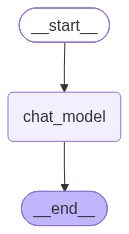

In [5]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you want to learn Agentic AI ?
================================ Human Message =================================
Name: Abdullah

Yes, I know about Agentic AI. But what others should I learn about?
================================== Ai Message ==================================

Great! If you already have a solid grasp of **Agentic AI** (i.e., AI systems that can set and pursue their own goals, plan, and act in the world), the next step is to broaden your expertise into the surrounding ecosystem. Below is a **structured learning map** that shows the most useful adjacent fields, why they matter for building robust, trustworthy agents, and concrete resources (books, courses, papers, tools) you can dive into right now.

---

## 1️⃣ Foundations of Intelligent Agents  

| Sub‑topic | What to Learn | Why It Matters for Agentic AI | Starter Resources |
|----------|---------------|------------

### Reducer
A practical challenge when working with messages is managing long-running conversations.

Long-running conversations result in `high token usage` and `latency` if we are not careful, because _we pass a growing list of messages to the model_.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

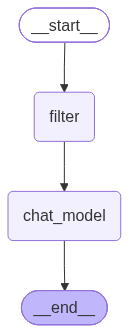

In [9]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Abdullah", id="2"))
messages.append(AIMessage("So you said you want to learn Agentic AI ?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about Agentic AI. But what others should I learn about?", name="Abdullah", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()



================================== Ai Message ==================================
Name: Bot

So you said you want to learn Agentic AI ?
================================ Human Message =================================
Name: Abdullah

Yes, I know about Agentic AI. But what others should I learn about?
================================== Ai Message ==================================

### 🎯  Where to Go After “Agentic AI”

Agentic AI (autonomous, goal‑directed software agents) sits at the crossroads of several fast‑moving sub‑fields.  If you already have a solid grasp of the core ideas—LLM‑driven planning, tool‑use, self‑reflection, and safety‑oriented alignment—think of your knowledge as a **hub**.  The spokes that radiate out from that hub are the areas that will make you a *well‑rounded* AI practitioner, researcher, or product builder.

Below is a **road‑map** (with optional depth levels) that shows the most useful “next‑step” domains, why they matter, and concrete resources you can dive 

### Filtering messages
If we don't need or want to modify the graph state, we can just filter the messages we pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

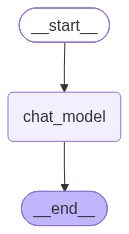

In [12]:
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Langgraph!", name="Abdullah"))

In [14]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Abdullah

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you want to learn Agentic AI ?
================================ Human Message =================================
Name: Abdullah

Yes, I know about Agentic AI. But what others should I learn about?
================================== Ai Message ==================================

### 🎯  Where to Go After “Agentic AI”

Agentic AI (autonomous, goal‑directed software agents) sits at the crossroads of several fast‑moving sub‑fields.  If you already have a solid grasp of the core ideas—LLM‑driven planning, tool‑use, self‑reflection, and safety‑oriented alignment—think of your knowledge as a **hub**.  The spokes that radiate out from that hub are the areas that will make you a *well‑rounded* AI prac

In [15]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Abdullah

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you want to learn Agentic AI ?
================================ Human Message =================================
Name: Abdullah

Yes, I know about Agentic AI. But what others should I learn about?
================================== Ai Message ==================================

### 🎯  Where to Go After “Agentic AI”

Agentic AI (autonomous, goal‑directed software agents) sits at the crossroads of several fast‑moving sub‑fields.  If you already have a solid grasp of the core ideas—LLM‑driven planning, tool‑use, self‑reflection, and safety‑oriented alignment—think of your knowledge as a **hub**.  The spokes that radiate out from that hub are the areas that will make you a *well‑rounded* AI prac

### Trim messages
Another approach is to `trim messages`, based upon a __set number of tokens__.

This restricts the _message history to a specified number of tokens_.

While filtering only returns a post-hoc subset of the messages between agents, _trimming restricts the number of tokens that a chat model can use to respond_.

See the trim_messages below.

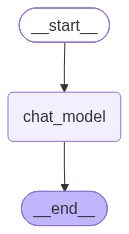

In [30]:
from langchain_core.messages import trim_messages

# A simple token estimator for models that do not implement message-token counting.
def rough_token_counter(messages):
    return sum(len(str(m.content).split()) for m in messages)

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=rough_token_counter,
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me how to track logs in langchain!", name="Abdullah"))

In [31]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=rough_token_counter,
            allow_partial=False
        )

[HumanMessage(content='Tell me how to track logs in langchain!', additional_kwargs={}, response_metadata={}, name='Abdullah')]

In [32]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [33]:
messages_out_trim['messages'][-1].pretty_print()

================================== Ai Message ==================================

## Quick‑Start Overview

| Goal | What you need | One‑liner code |
|------|----------------|----------------|
| **See every LLM request/response** | `langchain.callbacks` + a **callback handler** (e.g., `ConsoleCallbackHandler`, `FileCallbackHandler`, `LangChainTracer`) | `callbacks = [ConsoleCallbackHandler()]` |
| **Persist logs to a DB / file** | Choose a concrete handler (File, SQLite, Mongo, or a custom one) and pass it to the chain / agent | `callbacks = [FileCallbackHandler(path="logs.txt")]` |
| **Query logs later (search, filter, visualise)** | Use the **LangChain Tracing UI** (hosted on LangChain Cloud) or self‑host the **LangChain‑Trace‑Server** (FastAPI) | `from langchain_community.callbacks import LangChainTracer; tracer = LangChainTracer()` |
| **Add custom fields (e.g., request ID, user ID)** | Subclass `BaseCallbackHandler` and override the methods you care about | `class MyHandler(BaseCal